In [ ]:
import os
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import LabelEncoder
import pytorch_lightning as pl

class CryptoDataset(Dataset):
    def __init__(self, features: pd.DataFrame, labels: pd.DataFrame):
        """
        Args:
            features (pd.DataFrame): DataFrame containing the preprocessed feature data.
            labels (pd.DataFrame): DataFrame containing the unprocessed labels.
        """
        self.features = features.values  # Convert features to NumPy array
        self.labels = labels['&-class']  # Extract the labels column

        # Encode the labels (e.g., 'up'/'down') into integers
        self.label_encoder = LabelEncoder()
        self.labels_encoded = self.label_encoder.fit_transform(self.labels)

    def __len__(self):
        # Return the total number of samples in the dataset
        return len(self.features)

    def __getitem__(self, idx):
        """
        Returns a single sample from the dataset, indexed by `idx`.
        """
        feature = torch.tensor(self.features[idx], dtype=torch.float32)
        label = torch.tensor(self.labels_encoded[idx], dtype=torch.long)
        return feature, label

class CryptoDataModule(pl.LightningDataModule):
    def __init__(self, directory_path, batch_size=64, train_split=0.8):
        super().__init__()
        self.directory_path = directory_path
        self.batch_size = batch_size
        self.train_split = train_split

    def setup(self, stage=None):
        """
        Load data and split into training and validation datasets.
        """
        features_path = os.path.join(self.directory_path, 'features_filtered.parquet')
        labels_path = os.path.join(self.directory_path, 'labels_filtered.parquet')

        print("Loading parquet files...")
        df_features = pd.read_parquet(features_path)
        df_labels = pd.read_parquet(labels_path)
        print("Parquet files loaded successfully.")

        # Create dataset
        dataset = CryptoDataset(features=df_features, labels=df_labels)

        # Split dataset into training and validation sets
        train_size = int(self.train_split * len(dataset))
        val_size = len(dataset) - train_size
        self.train_dataset, self.val_dataset = random_split(dataset, [train_size, val_size])

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size, shuffle=False)

# Main execution
if __name__ == "__main__":
    # Directory path
    directory_path = '/allah/data/parquet'

    # Initialize DataModule
    data_module = CryptoDataModule(directory_path=directory_path, batch_size=64)

    # Setup datasets
    data_module.setup()

    # Test train DataLoader
    train_loader = data_module.train_dataloader()
    for batch_features, batch_labels in train_loader:
        print(f"Features batch shape: {batch_features.shape}")
        print(f"Labels batch shape: {batch_labels.shape}")
        break

    # Test validation DataLoader
    val_loader = data_module.val_dataloader()
    for batch_features, batch_labels in val_loader:
        print(f"Validation Features batch shape: {batch_features.shape}")
        print(f"Validation Labels batch shape: {batch_labels.shape}")
        break


In [2]:
import pytorch_lightning as pl
import torch
import torch.nn as nn
import torch.nn.functional as F

class CryptoPricePredictor(pl.LightningModule):
    def __init__(self, input_dim, hidden_dim=64, output_dim=2, dropout_rate=0.1):
        super(CryptoPricePredictor, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),   # First hidden layer
            nn.BatchNorm1d(hidden_dim),         # Batch normalization for better training stability
            nn.ReLU(),                          # Activation function
            nn.Dropout(dropout_rate),           # Dropout for regularization

            nn.Linear(hidden_dim, hidden_dim),  # Second hidden layer
            nn.BatchNorm1d(hidden_dim),         # Batch normalization
            nn.ReLU(),                          # Activation function
            nn.Dropout(dropout_rate),           # Dropout

            nn.Linear(hidden_dim, output_dim)   # Output layer
        )

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        features, labels = batch
        outputs = self(features)
        loss = F.cross_entropy(outputs, labels)
        
        # Training Accuracy
        acc = (outputs.argmax(dim=1) == labels).float().mean()
        self.log('train_loss', loss, on_step=True, on_epoch=True, prog_bar=True)
        self.log('train_acc', acc, on_step=True, on_epoch=True, prog_bar=True)
        
        # Precision for binary classification
        preds = outputs.argmax(dim=1)
        tp = ((preds == 1) & (labels == 1)).float().sum()  # True Positives
        fp = ((preds == 1) & (labels == 0)).float().sum()  # False Positives
        precision = tp / (tp + fp + 1e-8)  # Adding epsilon to avoid division by zero
        self.log('train_precision', precision, on_step=True, on_epoch=True, prog_bar=True)
        
        return loss

    def validation_step(self, batch, batch_idx):
        features, labels = batch
        outputs = self(features)
        loss = F.cross_entropy(outputs, labels)
        
        # Validation Accuracy
        acc = (outputs.argmax(dim=1) == labels).float().mean()
        self.log('val_loss', loss, on_step=True, on_epoch=True, prog_bar=True)
        self.log('val_acc', acc, on_step=True, on_epoch=True, prog_bar=True)
        
        # Precision for binary classification
        preds = outputs.argmax(dim=1)
        tp = ((preds == 1) & (labels == 1)).float().sum()  # True Positives
        fp = ((preds == 1) & (labels == 0)).float().sum()  # False Positives
        precision = tp / (tp + fp + 1e-8)  # Adding epsilon to avoid division by zero
        self.log('val_precision', precision, on_step=True, on_epoch=True, prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)


In [ ]:
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import EarlyStopping

# Define input dimensions based on the features
input_dim = 86  # Replace with the actual number of features in your dataset

# Initialize the model
model = CryptoPricePredictor(input_dim=input_dim, hidden_dim=64, output_dim=2)

# Initialize the data module
directory_path = '/allah/data/parquet'  # Update with your actual directory path
data_module = CryptoDataModule(directory_path=directory_path, batch_size=64)

# Initialize EarlyStopping callback
early_stopping = EarlyStopping(
    monitor="val_loss",  # Metric to monitor
    mode="min",          # "min" for minimizing (e.g., loss), "max" for maximizing (e.g., accuracy)
    patience=7,          # Number of epochs with no improvement before stopping
    verbose=True         # Print messages when stopping
)

# Initialize the Trainer with the EarlyStopping callback
trainer = Trainer(max_epochs=1000, callbacks=[early_stopping])

# Train the model
trainer.fit(model, datamodule=data_module)


In [44]:
!ls /allah/stuff/freq/userdir/backtest_results

backtest-result-2024-12-14_13-54-31.json
backtest-result-2024-12-14_13-54-31.meta.json
backtest-result-2024-12-14_13-54-31_market_change.feather
backtest-result-2024-12-14_14-37-51.json
backtest-result-2024-12-14_14-37-51.meta.json
backtest-result-2024-12-14_14-37-51_market_change.feather
backtest-result-2024-12-14_14-48-57.json
backtest-result-2024-12-14_14-48-57.meta.json
backtest-result-2024-12-14_14-48-57_market_change.feather
backtest-result-2024-12-14_14-49-36.json
backtest-result-2024-12-14_14-49-36.meta.json
backtest-result-2024-12-14_14-49-36_market_change.feather
backtest-result-2024-12-14_14-56-28.json
backtest-result-2024-12-14_14-56-28.meta.json
backtest-result-2024-12-14_14-56-28_market_change.feather


In [45]:
# read backtest-result-2024-12-14_11-37-27.json
# backtest-result-2024-12-14_11-37-27.meta.json
# backtest-result-2024-12-14_11-37-27_market_change.feather

import json
import pandas as pd

# Load the backtest results
with open('/allah/stuff/freq/userdir/backtest_results/backtest-result-2024-12-14_14-56-28.json', 'r') as f:
    backtest_results = json.load(f)

trades = backtest_results["strategy"]["TEMA50TrailingStopStrategy"]["trades"]
df_trades = pd.DataFrame(trades)

In [34]:
df_trades.columns

Index(['pair', 'stake_amount', 'max_stake_amount', 'amount', 'open_date',
       'close_date', 'open_rate', 'close_rate', 'fee_open', 'fee_close',
       'trade_duration', 'profit_ratio', 'profit_abs', 'exit_reason',
       'initial_stop_loss_abs', 'initial_stop_loss_ratio', 'stop_loss_abs',
       'stop_loss_ratio', 'min_rate', 'max_rate', 'is_open', 'enter_tag',
       'leverage', 'is_short', 'open_timestamp', 'close_timestamp', 'orders'],
      dtype='object')

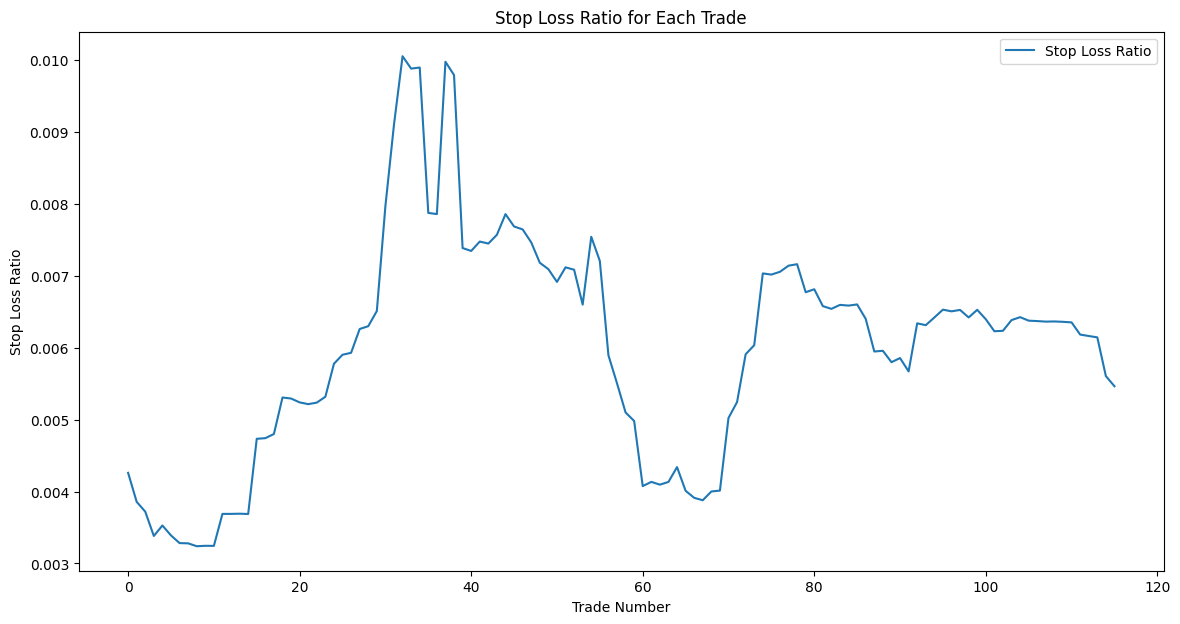

In [46]:
# df_trades['stop_loss_ratio']

# make this plotting df_trades['stop_loss_ratio']

import matplotlib.pyplot as plt

# Plot the trades
plt.figure(figsize=(14, 7))
plt.plot(-df_trades['stop_loss_ratio'], label='Stop Loss Ratio') 
plt.xlabel('Trade Number')
plt.ylabel('Stop Loss Ratio')
plt.title('Stop Loss Ratio for Each Trade')
plt.legend()

In [ ]:
backtest_results

In [50]:
# df_trades['stop_loss_ratio', 'open_date', 'close_date'] write this i wan to see mutiple columns 

df_trades[['stop_loss_ratio', 'open_date', 'close_date', 'enter_tag']].head(10)
# df_trades.columns

,stop_loss_ratio,open_date,close_date,enter_tag
0,-0.004260,2024-11-25 05:06:00+00:00,2024-11-25 06:03:00+00:00,tema50_up
1,-0.003857,2024-11-25 05:57:00+00:00,2024-11-25 06:06:00+00:00,tema50_down
2,-0.003720,2024-11-25 06:09:00+00:00,2024-11-25 06:39:00+00:00,tema50_up
3,-0.003383,2024-11-25 06:36:00+00:00,2024-11-25 07:00:00+00:00,tema50_up
4,-0.003528,2024-11-25 06:24:00+00:00,2024-11-25 07:21:00+00:00,tema50_down
5,-0.003391,2024-11-25 06:42:00+00:00,2024-11-25 07:21:00+00:00,tema50_down
6,-0.003283,2024-11-25 07:06:00+00:00,2024-11-25 07:21:00+00:00,tema50_up
7,-0.003280,2024-11-25 07:09:00+00:00,2024-11-25 07:21:00+00:00,tema50_down
8,-0.003240,2024-11-25 07:18:00+00:00,2024-11-25 07:21:00+00:00,tema50_up
9,-0.003246,2024-11-25 07:21:00+00:00,2024-11-25 07:21:00+00:00,tema50_down
